# Plot simulation timing
- This script is used to visualize timing.
- Simulations: CNTL, TRAF at FR-Capitole and UK-Manchester. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string

In [3]:
df_timing = pd.read_csv('data_for_figure/model_timing_summary.csv')
df_timing_average = df_timing.groupby(['Site', 'Scenario'], as_index=False).mean()
df_timing_average

,Site,Scenario,Init Time,Run Time,Final Time,ATM Run Time,LND Run Time,CPL Run Time
0,FR-Cap,cntl,281.9832,143.8246,0.0438,40.2110,46.4150,57.1986
1,FR-Cap,traffic,299.4834,145.5118,0.1004,40.4144,47.5494,57.5480
2,UK-MCR,cntl,314.7780,68.8706,0.0312,16.3776,24.1270,28.3660
3,UK-MCR,traffic,325.5998,70.6954,0.0278,16.3120,25.8194,28.5640


In [4]:
site_list = ['FR-Cap', 'UK-MCR']
scenario_list = ['cntl', 'traffic']
lc1 = '#1f78b4'
lc2 = '#e31a1c'
lc = [lc1, lc2]
bar_width = 0.35
handletextpad = 0.2
labelcolor = '#6b6b6b'
textcolor = '#000000'
x = 0.1
labelfont = 6
xwidth = 0.5
ymax_list = [600, 160]
title_list = ['Overall computational time (seconds)', 
              'Run time by component (seconds)']
pad = 1
length = 2
padding = 4

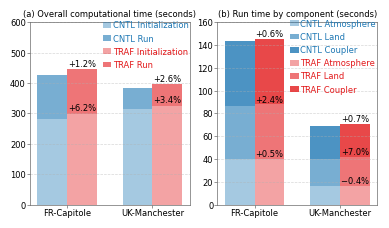

In [7]:
x = np.arange(len(df_timing_average['Site'].unique()))

fig, axes = plt.subplots(1, 2, figsize=(3.75,2.15))
ax = axes.flatten()

# First subplot: Init, Run, Final times
for i, scenario in enumerate(scenario_list):
    scenario_color = lc[i]
    scenario_label = ['CNTL', 'TRAF'][i]
    
    df_s = df_timing_average[df_timing_average['Scenario'] == scenario]
    
    # plot Init Time
    ax[0].bar(x + i*bar_width, df_s['Init Time'], bar_width,
              label=f'{scenario_label} Initialization', color=scenario_color, alpha=0.4)
    # plot Run Time (stacked on top)
    ax[0].bar(x + i*bar_width, df_s['Run Time'], bar_width,
              bottom=df_s['Init Time'], label=f'{scenario_label} Run', color=scenario_color, alpha=0.6)

    ax[1].bar(x + i*bar_width, df_s['ATM Run Time'], bar_width,
                label=f'{scenario_label} Atmosphere', color=scenario_color, alpha=0.4)
    ax[1].bar(x + i*bar_width, df_s['LND Run Time'], bar_width,
                label=f'{scenario_label} Land', bottom=df_s['ATM Run Time'], color=scenario_color, alpha=0.6)

    ax[1].bar(x + i*bar_width, df_s['CPL Run Time'], bar_width,
                label=f'{scenario_label} Coupler', bottom=df_s['ATM Run Time'] + df_s['LND Run Time'], color=scenario_color, alpha=0.8)
    if i >0:
        df_prev = df_timing_average[df_timing_average['Scenario'] == scenario_list[i-1]]
        change_pct_init = (df_s['Init Time'].values - df_prev['Init Time'].values) / df_prev['Init Time'].values * 100
        change_pct_run = (df_s['Run Time'].values - df_prev['Run Time'].values) / df_prev['Run Time'].values * 100
        change_pct_atm = (df_s['ATM Run Time'].values - df_prev['ATM Run Time'].values) / df_prev['ATM Run Time'].values * 100
        change_pct_lnd = (df_s['LND Run Time'].values - df_prev['LND Run Time'].values) / df_prev['LND Run Time'].values * 100
        change_pct_rest = (df_s['CPL Run Time'].values - df_prev['CPL Run Time'].values) / df_prev['CPL Run Time'].values * 100

        # Annotations
        bar_pos = x + i*bar_width 
        for j in range(len(site_list)):
            yoffset0 = 10
            ax[0].text(bar_pos[j], df_s['Init Time'].values[j] + yoffset0, f'+{change_pct_init[j]:.1f}%', ha='center', fontsize=labelfont)
            ax[0].text(bar_pos[j], df_s['Init Time'].values[j] + df_s['Run Time'].values[j] + yoffset0, f'+{change_pct_run[j]:.1f}%', ha='center', fontsize=labelfont)
            yoffset1 = 2
            if change_pct_atm[j]<0:
                sign = r'$-$' + f'{np.abs(change_pct_atm[j]):.1f}%'
            else:
                sign = f'+{change_pct_atm[j]:.1f}%'    
            ax[1].text(bar_pos[j], df_s['ATM Run Time'].values[j] + yoffset1, sign, ha='center', fontsize=labelfont)
            ax[1].text(bar_pos[j], df_s['ATM Run Time'].values[j] + df_s['LND Run Time'].values[j] + yoffset1, f'+{change_pct_lnd[j]:.1f}%', ha='center', fontsize=labelfont)
            ax[1].text(bar_pos[j], df_s['ATM Run Time'].values[j] + df_s['LND Run Time'].values[j] + df_s['CPL Run Time'].values[j] + yoffset1, f'+{change_pct_rest[j]:.1f}%', ha='center', fontsize=labelfont)
                       
for j in range(len(axes)):
    ymax = ymax_list[j]
    ax[j].set_ylim(0, ymax)
    ax[j].set_xticks(x+bar_width/2)
    ax[j].set_xticklabels(['FR-Capitole', 'UK-Manchester'], color = labelcolor, fontsize=labelfont)
    for s, spine in enumerate(ax[j].spines.values()):
        spine.set_linewidth(xwidth)
        spine.set_edgecolor(labelcolor)   
    ax[j].tick_params(axis='y', which='both', left=True, right=False, labelleft=True, labelcolor=textcolor, color=labelcolor,labelsize=labelfont,pad=pad, width = xwidth, length = length)
    ax[j].tick_params(axis='x', which='both', top=False, bottom=True, labelbottom=True, labelcolor=textcolor,color=labelcolor,labelsize=labelfont,pad=pad, width = xwidth, length = length)
    title = f'({string.ascii_lowercase[j]}) {title_list[j]}'
    ax[j].set_title(title, color=textcolor, fontsize=labelfont, pad=padding)
    ax[j].grid(axis='y', linestyle='--',linewidth=0.5, alpha=0.5)
    lines, labels = ax[j].get_legend_handles_labels()
    if j == 0:
         n=2
         y_loc = 0.7
    else:
         n=3
         y_loc = 0.565     
    legend = ax[j].legend(lines, labels, bbox_to_anchor=(0.725, y_loc), loc='lower center', frameon=False, 
                        handletextpad=handletextpad, fontsize=labelfont, ncol=1, handlelength=1)
    for t, text in enumerate(legend.get_texts()):
        text.set_color(lc[t//n])

plt.subplots_adjust(left=0.065, right=0.99, bottom=0.075, top=0.925, wspace=0.175, hspace= 0.35)
fig.savefig('computational_cost.png', dpi=300)            
fig.savefig('computational_cost.pdf', dpi=600)  